In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

data=pd.read_csv('lungcancer.csv')

d0=data[data['Result'] == 0]
d1=data[data['Result'] == 1]

index=['Count', 'Min', 'Max', 'Mean', 'std', 'Var', 'Median', '0%', '25%', '50%', '75%', 'IQR', 'Skewness', 'Kurtosis']
x=[
    d0['Age'].count(),
    d0['Age'].min(),
    d0['Age'].max(),
    d0['Age'].mean(),
    d0['Age'].std(),
    d0['Age'].var(),
    d0['Age'].median(),
    d0['Age'].quantile(0),
    d0['Age'].quantile(0.25),
    d0['Age'].quantile(0.5),
    d0['Age'].quantile(0.75),
    d0['Age'].quantile(0.75) - d0['Age'].quantile(0.25),
    d0['Age'].skew(),
    kurtosis(d0['Age'], fisher=False) 
]

y=[
    d1['Age'].count(),
    d1['Age'].min(),
    d1['Age'].max(),
    d1['Age'].mean(),
    d1['Age'].std(),
    d1['Age'].var(),
    d1['Age'].median(),
    d1['Age'].quantile(0),
    d1['Age'].quantile(0.25),
    d1['Age'].quantile(0.5),
    d1['Age'].quantile(0.75),
    d1['Age'].quantile(0.75) - d1['Age'].quantile(0.25),
    d1['Age'].skew(),
    kurtosis(d1['Age'], fisher=False) 
]

df=pd.DataFrame({
    'index': index,
    'TH1: Không ung thư phổi': x,
    'TH2: Ung thư phổi': y,
})

print(df)

       index  TH1: Không ung thư phổi  TH2: Ung thư phổi
0      Count                31.000000          28.000000
1        Min                18.000000          26.000000
2        Max                58.000000          77.000000
3       Mean                32.870968          53.428571
4        std                 9.745912          15.179002
5        Var                94.982796         230.402116
6     Median                33.000000          55.000000
7         0%                18.000000          26.000000
8        25%                25.500000          42.750000
9        50%                33.000000          55.000000
10       75%                38.000000          62.250000
11       IQR                12.500000          19.500000
12  Skewness                 0.594981          -0.241036
13  Kurtosis                 2.905405           2.110163


In [ ]:
#TH1:
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 32.87, và giá trị trung vị là 33.00. Như vậy, dữ liệu tập trung vào khoảng 32-33.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 94.98
# Độ lệch chuẩn (Standard deviation): sd = 9.75
# Khoảng giá trị: min = 18, max = 58 → range = 40
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 38.00 - 25.50 = 12.50
# Nhận xét: Dữ liệu có mức phân tán vừa phải, tuy nhiên có sự khác biệt giữa các giá trị nhưng không quá lớn.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = 0.594981, dữ liệu hơi lệch về phía phải (có đuôi dài hơn ở phía phải).
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.905405, đỉnh phân bố hơi thấp hơn so với phân phối chuẩn.
# Nhận xét: Dữ liệu hơi lệch về phía phải, đỉnh hơi thấp.

In [ ]:
#TH2:
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 53.43, và giá trị trung vị là 55.00. Như vậy, dữ liệu tập trung vào khoảng 53-55.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 230.40
# Độ lệch chuẩn (Standard deviation): sd = 15.18
# Khoảng giá trị: min = 26, max = 77 → range = 51
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 62.25 - 42.75 = 19.50
# Nhận xét: Dữ liệu phân tán nhiều hơn so với TH1, sự biến động lớn hơn.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = -0.241036, dữ liệu hơi lệch về phía trái.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.110163, đỉnh phân bố hơi thấp hơn so với phân phối chuẩn.
# Nhận xét: Dữ liệu hơi lệch về phía trái và có đỉnh nhọn, hai bên giảm với tốc độ vừa phải.

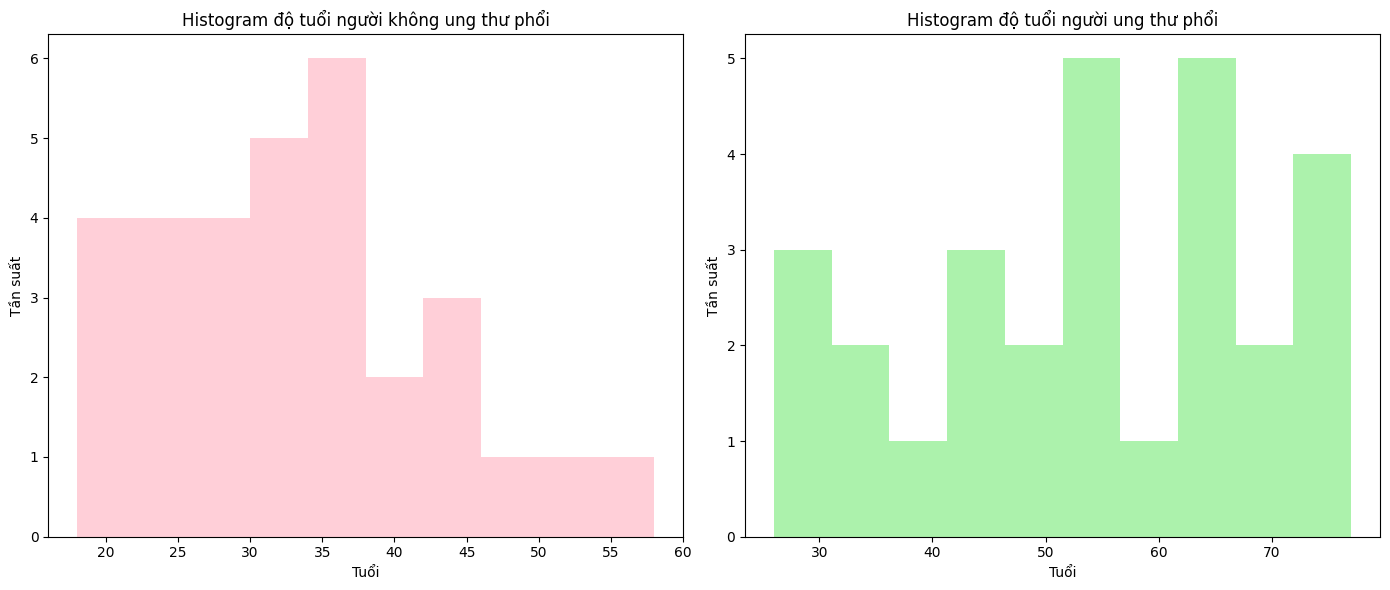

In [6]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(14, 6))

n1, bins1, patches1=ax1.hist(d0['Age'], bins=10, color='pink', alpha=0.75)
ax1.set_title('Histogram độ tuổi người không ung thư phổi')
ax1.set_xlabel('Tuổi')
ax1.set_ylabel('Tần suất')

n2, bins2, patches2=ax2.hist(d1['Age'], bins=10, color='lightgreen', alpha=0.75)
ax2.set_title('Histogram độ tuổi người ung thư phổi')
ax2.set_xlabel('Tuổi')
ax2.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x273b6a7c9b0>,
 [Text(1, 0, 'Không ung thư phổi'), Text(2, 0, 'Ung thư phổi')])

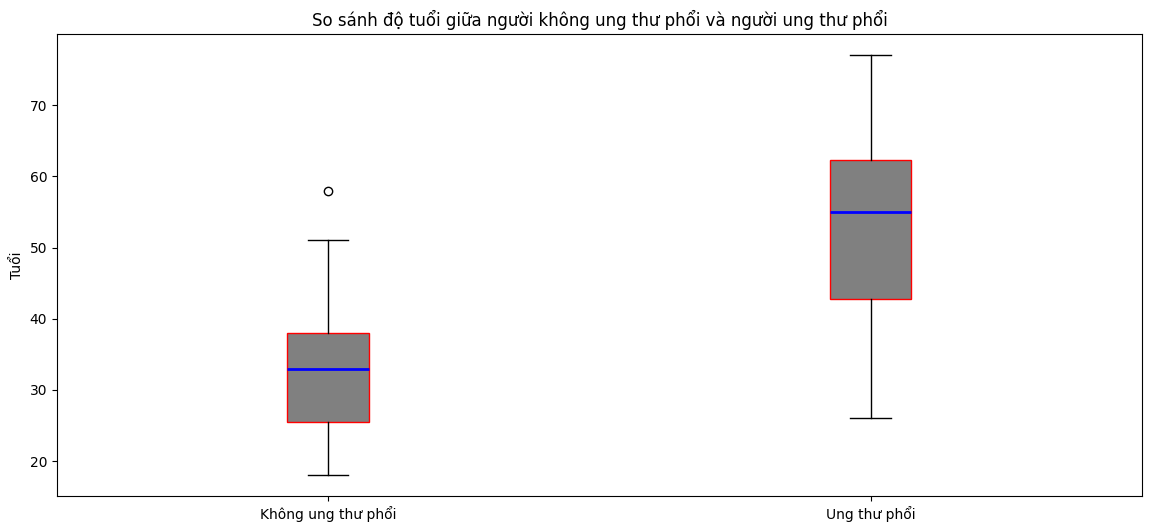

In [9]:
data = [d0['Age'], d1['Age']]
labels = ['Không ung thư phổi', 'Ung thư phổi']
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, 
            boxprops=dict(facecolor='gray', color='red'),
            medianprops=dict(color='blue', linewidth=2))
plt.title('So sánh độ tuổi giữa người không ung thư phổi và người ung thư phổi')
plt.ylabel('Tuổi')
plt.xticks([1, 2], labels)

In [10]:
x1=[
    d0['Smokes'].count(),
    d0['Smokes'].min(),
    d0['Smokes'].max(),
    d0['Smokes'].mean(),
    d0['Smokes'].std(),
    d0['Smokes'].var(),
    d0['Smokes'].median(),
    d0['Smokes'].quantile(0),
    d0['Smokes'].quantile(0.25),
    d0['Smokes'].quantile(0.5),
    d0['Smokes'].quantile(0.75),
    d0['Smokes'].quantile(0.75) - d0['Smokes'].quantile(0.25),
    d0['Smokes'].skew(),
    kurtosis(d0['Smokes'], fisher=False) 
]

y1=[
    d1['Smokes'].count(),
    d1['Smokes'].min(),
    d1['Smokes'].max(),
    d1['Smokes'].mean(),
    d1['Smokes'].std(),
    d1['Smokes'].var(),
    d1['Smokes'].median(),
    d1['Smokes'].quantile(0),
    d1['Smokes'].quantile(0.25),
    d1['Smokes'].quantile(0.5),
    d1['Smokes'].quantile(0.75),
    d1['Smokes'].quantile(0.75) - d1['Smokes'].quantile(0.25),
    d1['Smokes'].skew(),
    kurtosis(d1['Smokes'], fisher=False) 
]

df=pd.DataFrame({
    'index': index,
    'TH1: Không ung thư phổi': x1,
    'TH2: Ung thư phổi': y1,
})

print(df)

       index  TH1: Không ung thư phổi  TH2: Ung thư phổi
0      Count                31.000000          28.000000
1        Min                 0.000000           3.000000
2        Max                25.000000          34.000000
3       Mean                12.258065          18.178571
4        std                 7.215575           7.746223
5        Var                52.064516          60.003968
6     Median                12.000000          20.000000
7         0%                 0.000000           3.000000
8        25%                 9.000000          15.000000
9        50%                12.000000          20.000000
10       75%                19.000000          20.000000
11       IQR                10.000000           5.000000
12  Skewness                -0.149839          -0.410276
13  Kurtosis                 2.201710           3.072403


In [ ]:
# TH1: Không ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 12.26, và giá trị trung vị là 12.00. Dữ liệu tập trung vào khoảng 12.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 52.06
# Độ lệch chuẩn (Standard deviation): sd = 7.22
# Khoảng giá trị: min = 0, max = 25 → range = 25
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 19 - 9 = 10
# Nhận xét: Dữ liệu có sự biến động khá vừa phải, với phạm vi dao động tương đối lớn, nhưng dữ liệu phân bố khá gần nhau trong khoảng từ 9 đến 19.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = -0.149839, dữ liệu hơi lệch về phía trái nhưng không quá rõ ràng.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.201710, đỉnh phân bố gần với phân phối chuẩn.
# Nhận xét: Dữ liệu gần như phân bố đều với một chút lệch nhẹ về phía trái và đỉnh dữ liệu không quá nhọn.

In [ ]:
# TH2: Ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 18.18, và giá trị trung vị là 20.00. Dữ liệu tập trung vào khoảng 18-20.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 60.00
# Độ lệch chuẩn (Standard deviation): sd = 7.75
# Khoảng giá trị: min = 3, max = 34 → range = 31
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 20 - 15 = 5
# Nhận xét: Dữ liệu có sự phân tán rộng hơn so với TH1, nhưng khoảng cách giữa các giá trị trung bình và phần tư trên (Q3) tương đối gần nhau.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = -0.410276, dữ liệu hơi lệch về phía trái.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 3.072403, đỉnh phân bố nhọn hơn một chút so với phân phối chuẩn.
# Nhận xét: Dữ liệu hơi lệch về phía trái và có đỉnh nhọn, hai bên giảm với tốc độ vừa phải.

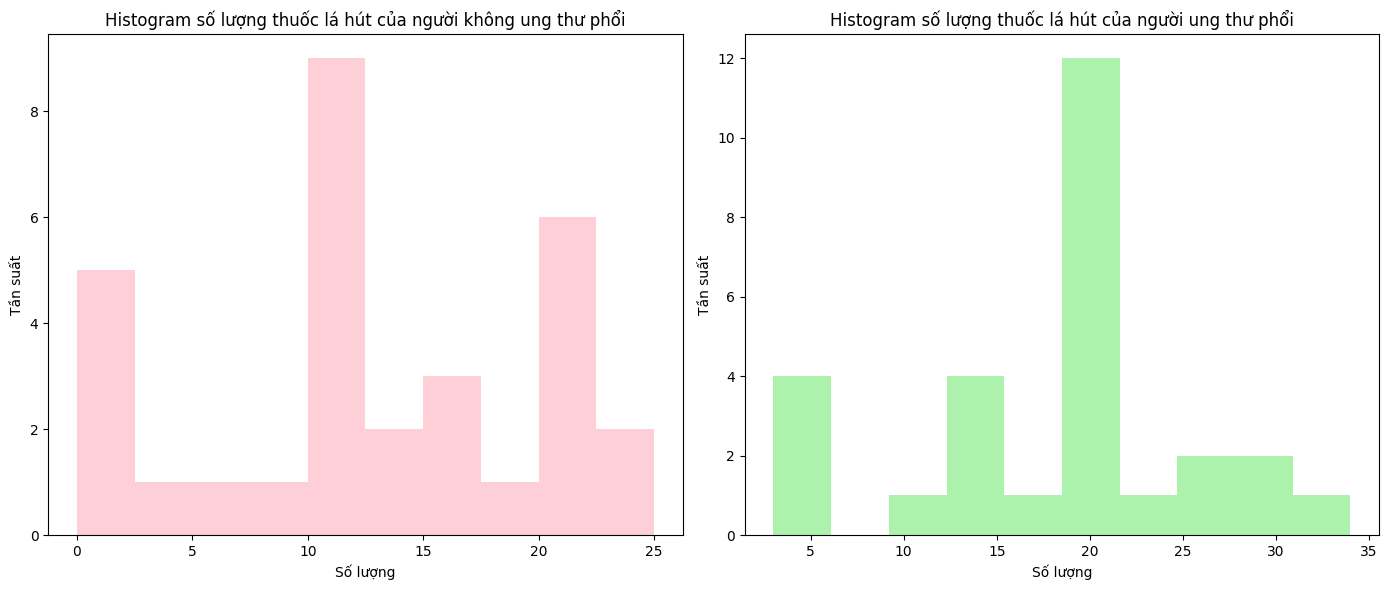

In [12]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(14, 6))

n1, bins1, patches1=ax1.hist(d0['Smokes'], bins=10, color='pink', alpha=0.75)
ax1.set_title('Histogram số lượng thuốc lá hút của người không ung thư phổi')
ax1.set_xlabel('Số lượng')
ax1.set_ylabel('Tần suất')

n2, bins2, patches2=ax2.hist(d1['Smokes'], bins=10, color='lightgreen', alpha=0.75)
ax2.set_title('Histogram số lượng thuốc lá hút của người ung thư phổi')
ax2.set_xlabel('Số lượng')
ax2.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x273bc3d6f30>,
 [Text(1, 0, 'Không ung thư phổi'), Text(2, 0, 'Ung thư phổi')])

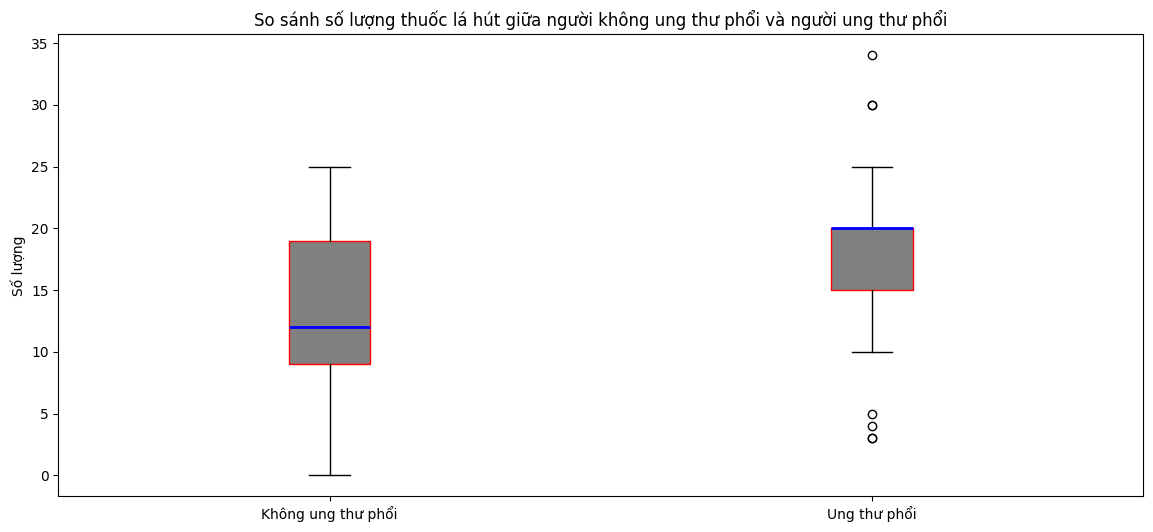

In [26]:
data = [d0['Smokes'], d1['Smokes']]
labels = ['Không ung thư phổi', 'Ung thư phổi']
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, 
            boxprops=dict(facecolor='gray', color='red'),
            medianprops=dict(color='blue', linewidth=2))
plt.title('So sánh số lượng thuốc lá hút giữa người không ung thư phổi và người ung thư phổi')
plt.ylabel('Số lượng')
plt.xticks([1, 2], labels)

In [16]:
x2=[
    d0['AreaQ'].count(),
    d0['AreaQ'].min(),
    d0['AreaQ'].max(),
    d0['AreaQ'].mean(),
    d0['AreaQ'].std(),
    d0['AreaQ'].var(),
    d0['AreaQ'].median(),
    d0['AreaQ'].quantile(0),
    d0['AreaQ'].quantile(0.25),
    d0['AreaQ'].quantile(0.5),
    d0['AreaQ'].quantile(0.75),
    d0['AreaQ'].quantile(0.75) - d0['AreaQ'].quantile(0.25),
    d0['AreaQ'].skew(),
    kurtosis(d0['AreaQ'], fisher=False) 
]

y2=[
    d1['AreaQ'].count(),
    d1['AreaQ'].min(),
    d1['AreaQ'].max(),
    d1['AreaQ'].mean(),
    d1['AreaQ'].std(),
    d1['AreaQ'].var(),
    d1['AreaQ'].median(),
    d1['AreaQ'].quantile(0),
    d1['AreaQ'].quantile(0.25),
    d1['AreaQ'].quantile(0.5),
    d1['AreaQ'].quantile(0.75),
    d1['AreaQ'].quantile(0.75) - d1['AreaQ'].quantile(0.25),
    d1['AreaQ'].skew(),
    kurtosis(d1['AreaQ'], fisher=False) 
]

df=pd.DataFrame({
    'index': index,
    'TH1: Không ung thư phổi': x2,
    'TH2: Ung thư phổi': y2,
})

print(df)

       index  TH1: Không ung thư phổi  TH2: Ung thư phổi
0      Count                31.000000          28.000000
1        Min                 4.000000           1.000000
2        Max                10.000000           7.000000
3       Mean                 6.935484           3.285714
4        std                 1.631676           1.674584
5        Var                 2.662366           2.804233
6     Median                 7.000000           3.000000
7         0%                 4.000000           1.000000
8        25%                 5.500000           2.000000
9        50%                 7.000000           3.000000
10       75%                 8.000000           5.000000
11       IQR                 2.500000           3.000000
12  Skewness                 0.061249           0.275614
13  Kurtosis                 1.962871           2.186429


In [ ]:
# TH1: Không ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 6.94, và giá trị trung vị là 7.00. Dữ liệu tập trung vào khoảng 6.9 - 7.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 2.66
# Độ lệch chuẩn (Standard deviation): sd = 1.63
# Khoảng giá trị: min = 4, max = 10 → range = 6
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 8.00 - 5.50 = 2.50
# Nhận xét: Dữ liệu có mức phân tán khá nhỏ, tập trung xung quanh giá trị trung bình và phần tư vị trên.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = 0.061249, dữ liệu gần như đối xứng, không bị lệch đáng kể.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 1.962871, đỉnh phân bố thấp hơn so với phân phối chuẩn.
# Nhận xét: Dữ liệu gần như phân bố đều, không có sự lệch nhiều và đỉnh dữ liệu không quá nhọn.

In [ ]:
# TH2: Ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 3.29, và giá trị trung vị là 3.00. Dữ liệu tập trung vào khoảng 3.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 2.80
# Độ lệch chuẩn (Standard deviation): sd = 1.67
# Khoảng giá trị: min = 1, max = 7 → range = 6
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 5.00 - 2.00 = 3.00
# Nhận xét: Dữ liệu phân tán tương đối đồng đều, nhưng mức độ biến động hơi cao hơn so với TH1.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = 0.275614, dữ liệu hơi lệch về phía phải.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.186429, đỉnh dữ liệu gần với phân phối chuẩn.
# Nhận xét: Dữ liệu hơi lệch về phía phải, nhưng sự lệch không đáng kể, và đỉnh phân bố gần như bình thường.

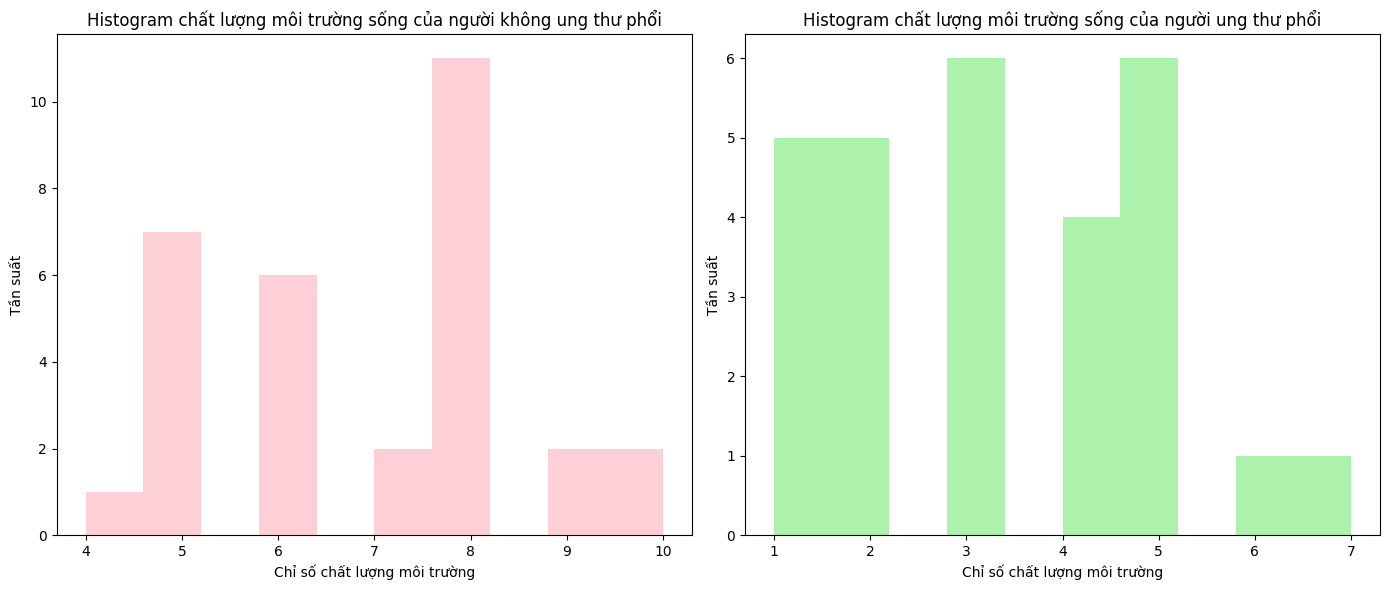

In [18]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(14, 6))

n1, bins1, patches1=ax1.hist(d0['AreaQ'], bins=10, color='pink', alpha=0.75)
ax1.set_title('Histogram chất lượng môi trường sống của người không ung thư phổi')
ax1.set_xlabel('Chỉ số chất lượng môi trường')
ax1.set_ylabel('Tần suất')

n2, bins2, patches2=ax2.hist(d1['AreaQ'], bins=10, color='lightgreen', alpha=0.75)
ax2.set_title('Histogram chất lượng môi trường sống của người ung thư phổi')
ax2.set_xlabel('Chỉ số chất lượng môi trường')
ax2.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x273b6ab6240>,
 [Text(1, 0, 'Không ung thư phổi'), Text(2, 0, 'Ung thư phổi')])

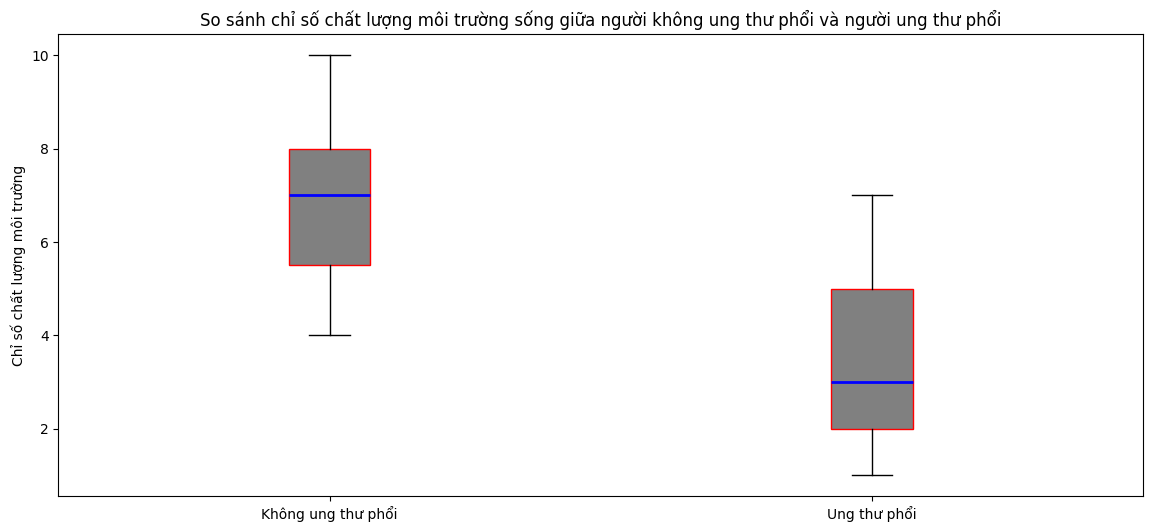

In [20]:
data = [d0['AreaQ'], d1['AreaQ']]
labels = ['Không ung thư phổi', 'Ung thư phổi']
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, 
            boxprops=dict(facecolor='gray', color='red'),
            medianprops=dict(color='blue', linewidth=2))
plt.title('So sánh chỉ số chất lượng môi trường sống giữa người không ung thư phổi và người ung thư phổi')
plt.ylabel('Chỉ số chất lượng môi trường')
plt.xticks([1, 2], labels)

In [21]:
x3=[
    d0['Alkhol'].count(),
    d0['Alkhol'].min(),
    d0['Alkhol'].max(),
    d0['Alkhol'].mean(),
    d0['Alkhol'].std(),
    d0['Alkhol'].var(),
    d0['Alkhol'].median(),
    d0['Alkhol'].quantile(0),
    d0['Alkhol'].quantile(0.25),
    d0['Alkhol'].quantile(0.5),
    d0['Alkhol'].quantile(0.75),
    d0['Alkhol'].quantile(0.75) - d0['Alkhol'].quantile(0.25),
    d0['Alkhol'].skew(),
    kurtosis(d0['Alkhol'], fisher=False) 
]

y3=[
    d1['Alkhol'].count(),
    d1['Alkhol'].min(),
    d1['Alkhol'].max(),
    d1['Alkhol'].mean(),
    d1['Alkhol'].std(),
    d1['Alkhol'].var(),
    d1['Alkhol'].median(),
    d1['Alkhol'].quantile(0),
    d1['Alkhol'].quantile(0.25),
    d1['Alkhol'].quantile(0.5),
    d1['Alkhol'].quantile(0.75),
    d1['Alkhol'].quantile(0.75) - d1['Alkhol'].quantile(0.25),
    d1['Alkhol'].skew(),
    kurtosis(d1['Alkhol'], fisher=False) 
]

df=pd.DataFrame({
    'index': index,
    'TH1: Không ung thư phổi': x3,
    'TH2: Ung thư phổi': y3,
})

print(df)

       index  TH1: Không ung thư phổi  TH2: Ung thư phổi
0      Count                31.000000          28.000000
1        Min                 0.000000           3.000000
2        Max                 4.000000           8.000000
3       Mean                 1.419355           5.250000
4        std                 1.118755           1.669442
5        Var                 1.251613           2.787037
6     Median                 1.000000           5.000000
7         0%                 0.000000           3.000000
8        25%                 0.500000           4.000000
9        50%                 1.000000           5.000000
10       75%                 2.000000           6.000000
11       IQR                 1.500000           2.000000
12  Skewness                 0.292019           0.446841
13  Kurtosis                 2.268528           2.059723


In [ ]:
# TH1: Không ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 1.42, và giá trị trung vị là 1.00. Dữ liệu tập trung vào khoảng 1.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 1.25
# Độ lệch chuẩn (Standard deviation): sd = 1.12
# Khoảng giá trị: min = 0, max = 4 → range = 4
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 2.00 - 0.50 = 1.50
# Nhận xét: Dữ liệu có sự phân tán vừa phải, tập trung chủ yếu quanh giá trị nhỏ (0-2).
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = 0.292019, dữ liệu hơi lệch về phía phải, nhưng không quá đáng kể.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.268528, đỉnh dữ liệu gần với phân phối chuẩn.
# Nhận xét: Dữ liệu gần như phân bố đều, có một chút lệch nhẹ về phía phải, và đỉnh dữ liệu không quá nhọn.

In [ ]:
# TH2: Ung thư phổi
# Vị trí tập trung của dữ liệu: Giá trị trung bình là 5.25, và giá trị trung vị là 5.00. Dữ liệu tập trung vào khoảng 5.
# Tính biến động của dữ liệu:
# Phương sai (Variance): var = 2.79
# Độ lệch chuẩn (Standard deviation): sd = 1.67
# Khoảng giá trị: min = 3, max = 8 → range = 5
# Khoảng cách giữa 2 phần tư vị (IQR): Q3-Q1 = 6.00 - 4.00 = 2.00
# Nhận xét: Dữ liệu có sự phân tán vừa phải, nhưng các giá trị nằm trong khoảng nhỏ từ 3 đến 8, với trung tâm rõ rệt ở giá trị 5.
# Hình dạng phân bố của dữ liệu:
# Độ lệch (Skewness): Skewness = 0.446841, dữ liệu hơi lệch về phía phải.
# Độ bè nhọn của đỉnh dữ liệu (Kurtosis): Kurtosis = 2.059723, đỉnh dữ liệu không quá nhọn, gần với phân phối chuẩn.
# Nhận xét: Dữ liệu có xu hướng lệch về phía phải, nhưng mức độ lệch không quá rõ ràng, và đỉnh phân bố tương đối bình thường.

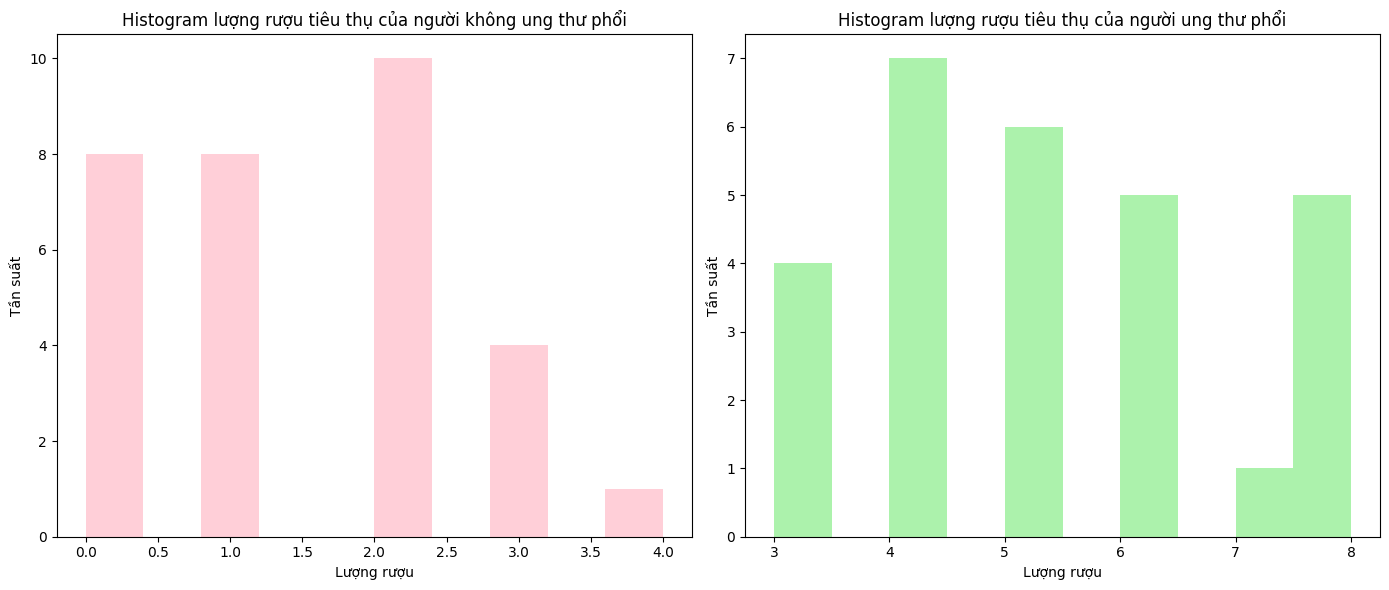

In [23]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(14, 6))

n1, bins1, patches1=ax1.hist(d0['Alkhol'], bins=10, color='pink', alpha=0.75)
ax1.set_title('Histogram lượng rượu tiêu thụ của người không ung thư phổi')
ax1.set_xlabel('Lượng rượu')
ax1.set_ylabel('Tần suất')

n2, bins2, patches2=ax2.hist(d1['Alkhol'], bins=10, color='lightgreen', alpha=0.75)
ax2.set_title('Histogram lượng rượu tiêu thụ của người ung thư phổi')
ax2.set_xlabel('Lượng rượu')
ax2.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x273bb0e9be0>,
 [Text(1, 0, 'Không ung thư phổi'), Text(2, 0, 'Ung thư phổi')])

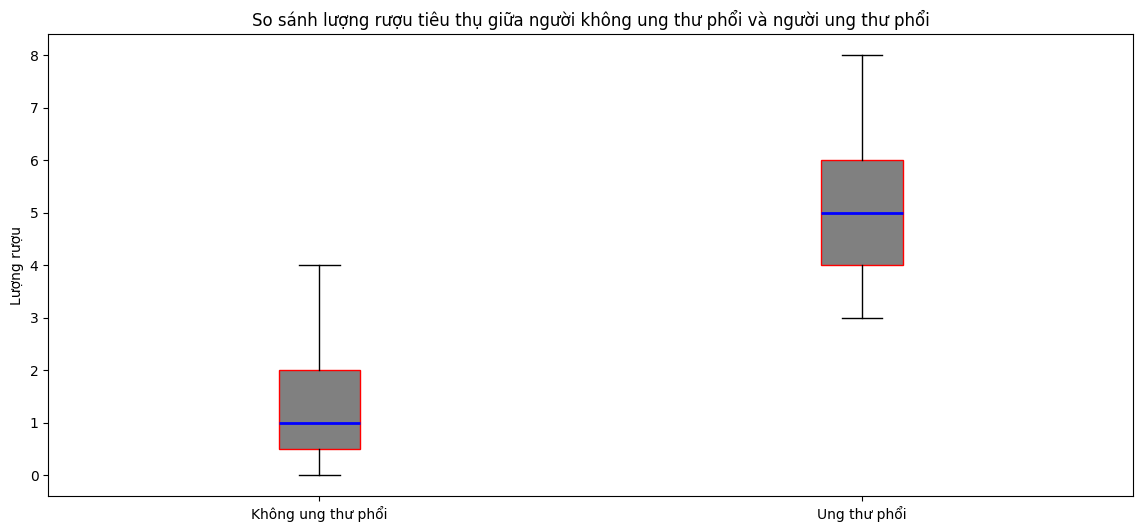

In [25]:
data = [d0['Alkhol'], d1['Alkhol']]
labels = ['Không ung thư phổi', 'Ung thư phổi']
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, 
            boxprops=dict(facecolor='gray', color='red'),
            medianprops=dict(color='blue', linewidth=2))
plt.title('So sánh lượng rượu tiêu thụ giữa người không ung thư phổi và người ung thư phổi')
plt.ylabel('Lượng rượu')
plt.xticks([1, 2], labels)